# LLAMA ARCHITECTURE FOR REFERENCE

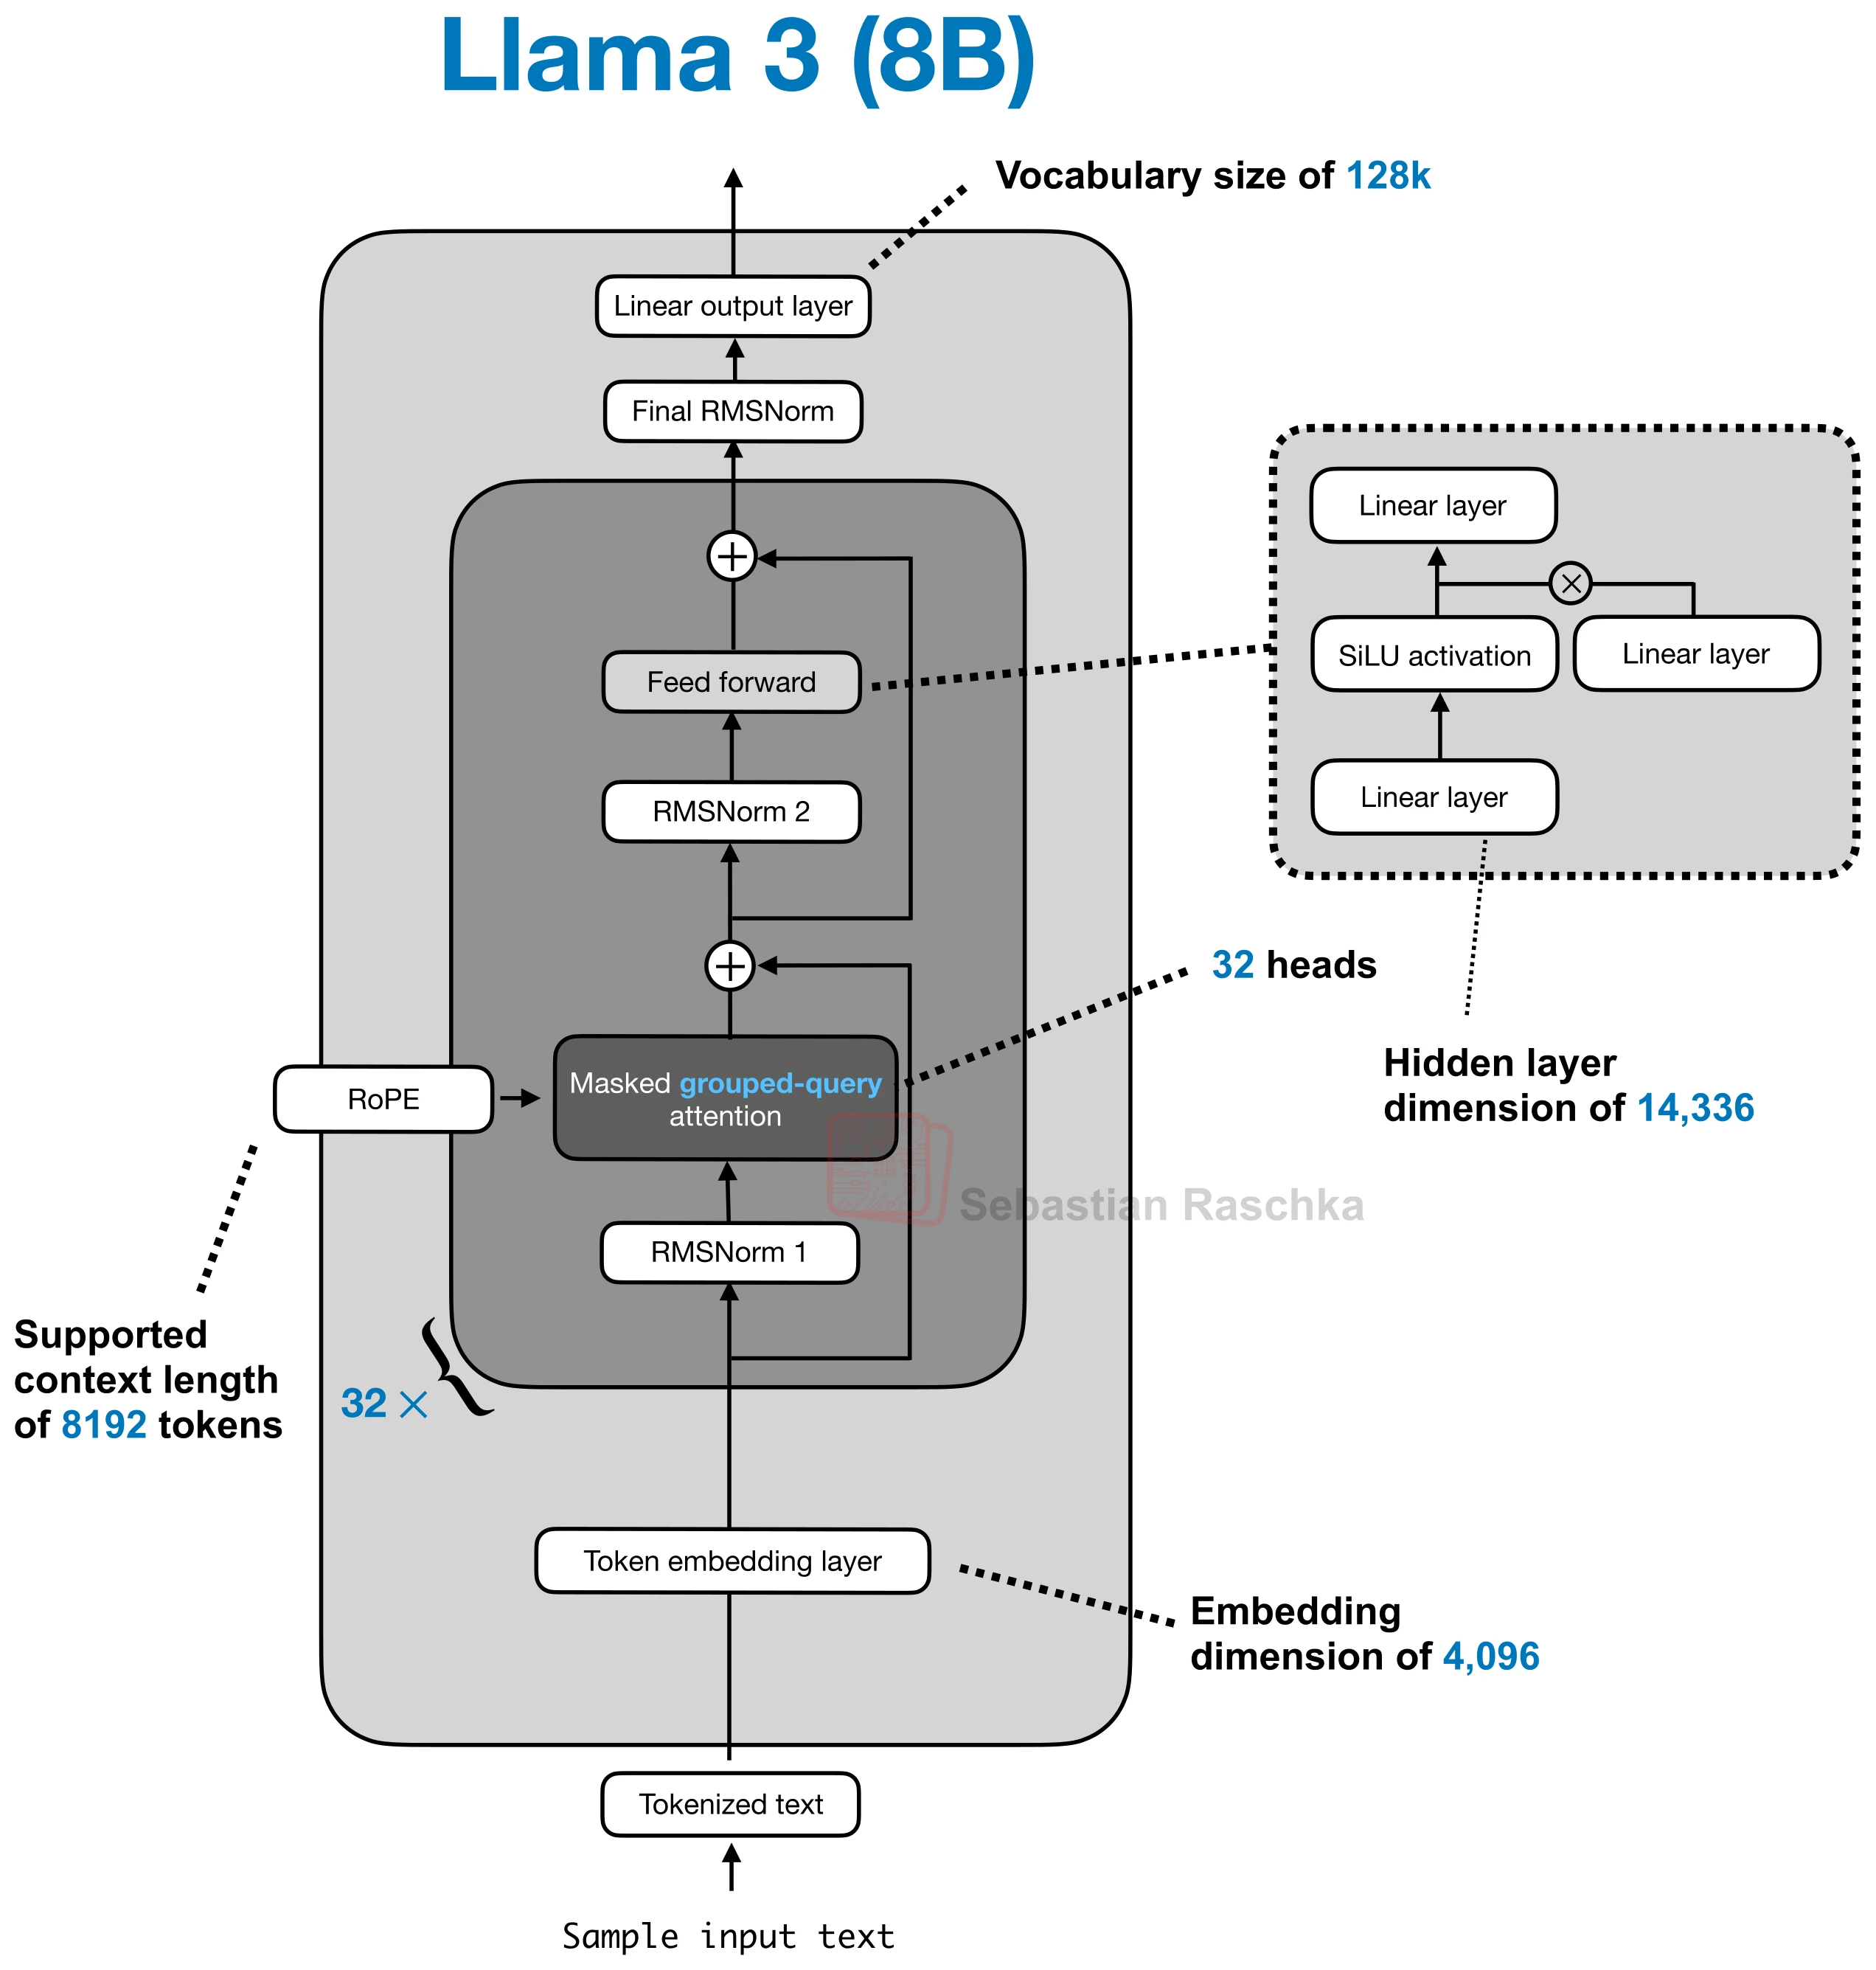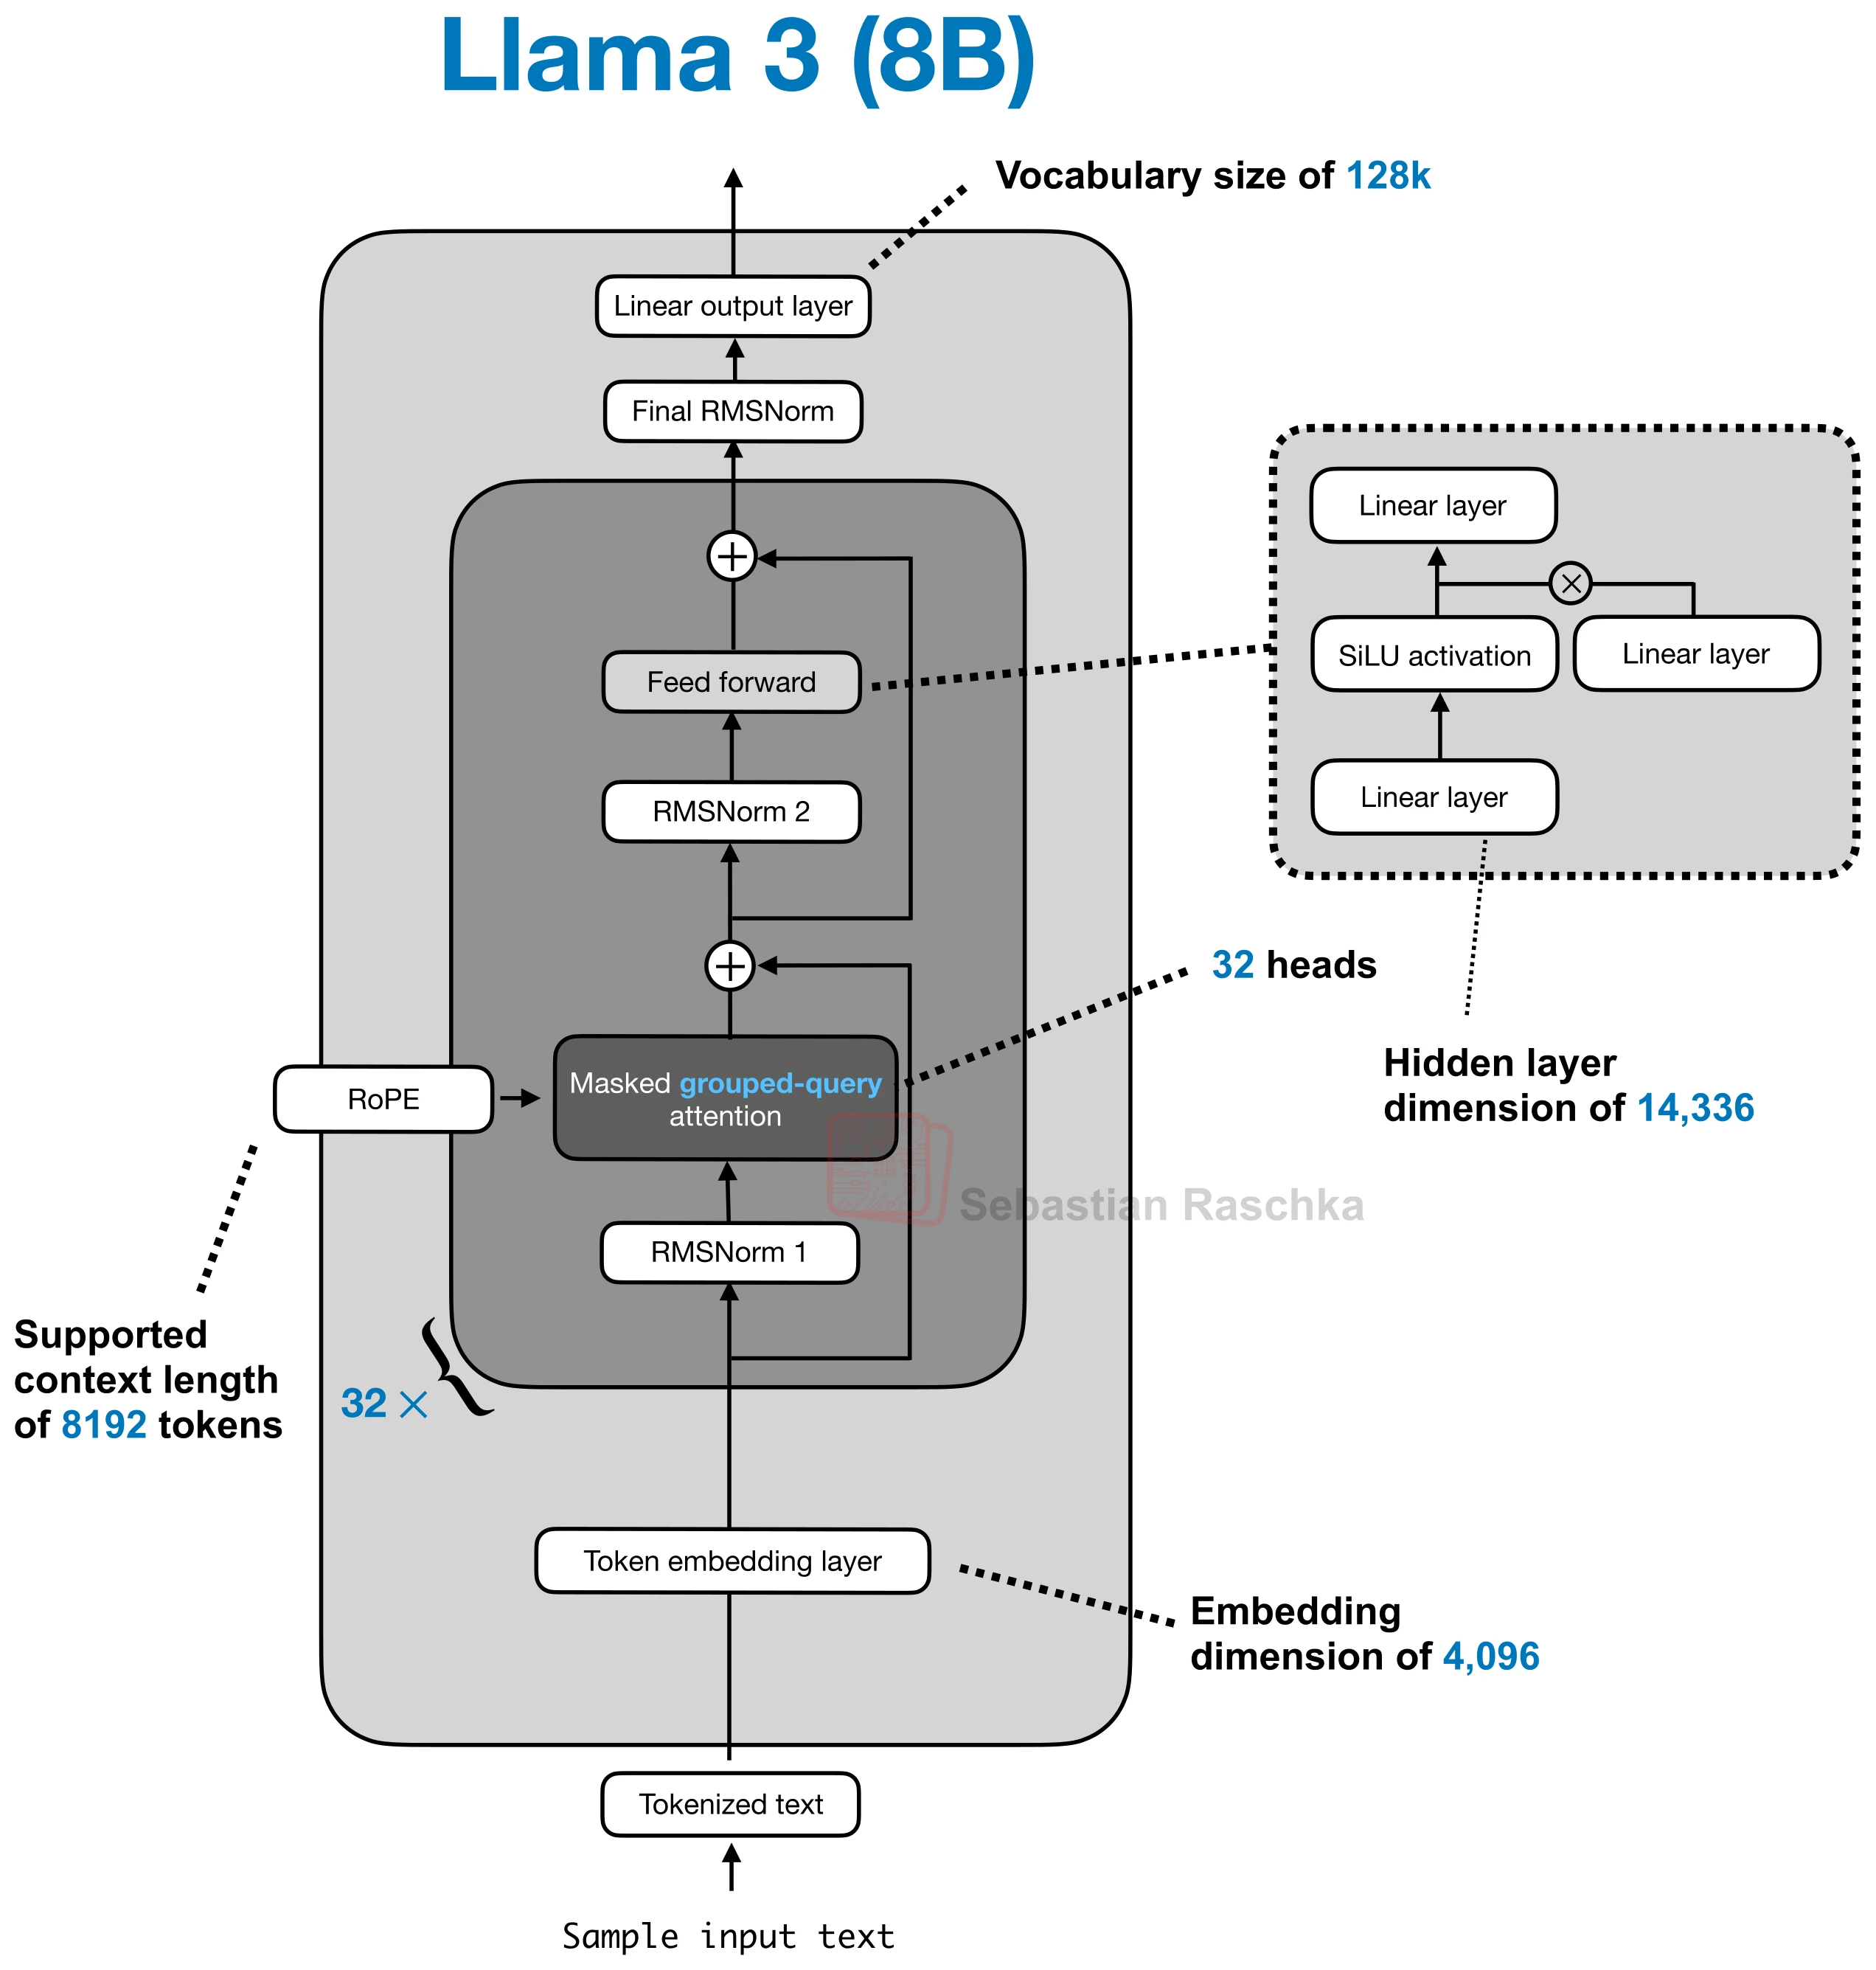

#  IMPORTING MODULES AND PREPARING THE DATASET

In [3]:
#IMPORT NECESSARY MODULES
import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
import tiktoken

In [4]:
#STRUCTURING THE DATASET

class LLAMADataset(Dataset) : 
    def __init__ (self , txt , tokenizer , max_length , stride) :
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt , allowed_special={"<|endoftext|>"})

        for i in range(0 , len(token_ids) - max_length , stride) :
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self) :
        return len(self.input_ids)

    def __getitem__(self , idx) :
        return self.input_ids[idx] , self.target_ids[idx]



In [5]:
#FUNCTION TO LOAD THE DATASET ( MAINLY FORBATCHING THE DATA)

def DATALOADER( input_text ,
                batch_size = 8 ,
                max_length = 256 ,
                stride = 128 ,
                shuffle = True ,
                drop_last = True ,
                num_workers = 0) :

    #Procure the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    #Create the dataset
    dataset = LLAMADataset(input_text , tokenizer , max_length , stride)

    #Batch the data
    dataloader = DataLoader(dataset ,
                            batch_size = batch_size ,
                            shuffle = shuffle ,
                            drop_last = drop_last ,
                            num_workers = num_workers
                           )

    return dataloader

# CLASSES FOR THE COMPONENTS OF THE LLAMA TRANSFORMER

In [6]:
# Root Mean Square Normalization Class

class RMSNorm(nn.Module) :
    def __init__ (self , embedding_dimension) :
        super().__init__()
        self.scale = nn.Parameter(torch.ones(embedding_dimension))
        self.epsilon = 1e-5 #Small constant to make sure denominator is not zero

    def forward(self , x) :
        std_dev = x.std(dim = - 1 , keepdim=True , unbiased = True) #unbiased = True to caculate population variance , not sample
        rms_x = x / (std_dev + self.epsilon)
        return self.scale * rms_x

In [7]:
# The ROPE Positional Embedding Function
def RoPE(x, theta_base=10_000):
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, device=x.device).float() / head_dim))

    positions = torch.arange(seq_len, device=x.device)

    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)
    angles = torch.cat([angles, angles], dim=-1)

    cos = torch.cos(angles).unsqueeze(0).unsqueeze(0)
    sin = torch.sin(angles).unsqueeze(0).unsqueeze(0)

    x1 = x[..., :head_dim // 2]
    x2 = x[..., head_dim // 2:]

    rotated = torch.cat([-x2, x1], dim=-1)

    return (x * cos + rotated * sin).to(dtype=x.dtype)

In [8]:
class MaskedGroupedQueryAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length, num_heads, num_kv_groups, qkv_bias=False):
        super().__init__()

        #Raising divisibility errors
        assert d_out % num_heads == 0, "Number of heads must divide output dimension"
        assert num_heads % num_kv_groups == 0, "Number of heads must divide number of KV groups"
        
        #Assigning the necessary attributes
        self.d_out = d_out
        self.num_heads = num_heads
        self.num_kv_groups = num_kv_groups
        self.head_dim = d_out // num_heads
        self.group_size = num_heads // num_kv_groups

        # Initialize weight matrices
        self.W_Query = nn.Linear(d_in,self.num_heads * self.head_dim,bias=qkv_bias)
        self.W_Key = nn.Linear(d_in,self.num_kv_groups * self.head_dim,bias=qkv_bias)
        self.W_Value = nn.Linear(d_in,self.num_kv_groups * self.head_dim,bias=qkv_bias)

        # Output Linear layer --> this is for model learning relationships between various heads
        self.output_proj = nn.Linear(d_out,d_out,bias=False)

        #Initializing a non-trainable mask
        self.register_buffer("mask",torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):

        #Procure the shape of the input
        n_batches, n_tokens, _ = x.shape

        # Compute Q, K and V Matrices
        queries = self.W_Query(x)
        keys = self.W_Key(x)
        values = self.W_Value(x)

        # Reshape into KV Groups/heads
        queries = queries.view(n_batches,n_tokens,self.num_heads,self.head_dim)
        keys = keys.view(n_batches,n_tokens,self.num_kv_groups,self.head_dim)
        values = values.view(n_batches,n_tokens,self.num_kv_groups,self.head_dim)

        #Transpose for appropriate matrix multiplications
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # Apply Rotary Positional Embeddings
        queries = RoPE(queries)
        keys = RoPE(keys)

        # Repeat KV heads to match query heads
        keys = keys.repeat_interleave(self.group_size, dim=1)
        values = values.repeat_interleave(self.group_size, dim=1)

        # Compute attention scores
        attention_scores = queries @ keys.transpose(-2, -1)

        # Compute weights
        mask = self.mask[:n_tokens, :n_tokens].bool()
        attention_scores.masked_fill_(mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores / (self.head_dim ** 0.5),dim=-1)

        # Compute context vectors
        context_vec = attention_weights @ values
        context_vec = context_vec.transpose(1, 2).contiguous().view(n_batches, n_tokens, self.d_out)
        
        # Final attention Linear layer
        context_vec = self.output_proj(context_vec)

        return context_vec

In [9]:
#SiLU Activation Function
class SiLU(nn.Module) :
    def __init__(self) :
        super().__init__()

    def forward(self , x) :
        sigmoid = 1 / (1 + torch.exp(-x))
        return x * sigmoid

In [10]:
#FeedForward Neural Network
class FeedForward(nn.Module) :
    def __init__(self , cfg) :
        super().__init__()
        self.linear1 = nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]) ##Expand
        self.silu = SiLU()
        self.linear2 = nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"])
        self.linear3 = nn.Linear(4 * cfg["emb_dim"] , cfg["emb_dim"])
    def forward(self , x) :
        x_l1 = self.linear1(x)
        x_l2 = self.linear2(x)
        x_silu_l2 = self.silu(x_l1) * x_l2
        x = self.linear3(x_silu_l2)
        return x
        
        

# THE TRANSFORMER CLASS

In [11]:
class LLAMATransformer(nn.Module) :
    def __init__(self , cfg) :
        super().__init__()
        self.rms_norm_1 = RMSNorm(cfg["emb_dim"])
        self.attention = MaskedGroupedQueryAttention(
                         d_in=cfg["emb_dim"],
                         d_out=cfg["emb_dim"],
                         context_length=cfg["context_length"],
                         num_heads=cfg["n_heads"],
                         num_kv_groups = cfg["n_kv_groups"],
                         qkv_bias=cfg["qkv_bias"])
        self.dropout= nn.Dropout(p=0.2)
        self.rms_norm_2 = RMSNorm(cfg["emb_dim"])
        self.feed_forward = FeedForward(cfg)
    def forward(self , x) :
        shortcut = x
        x = self.rms_norm_1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut
        shortcut = x
        x = self.rms_norm_2(x)
        x = self.feed_forward(x)
        x = self.dropout(x)
        x = x + shortcut
        return x
        

# THE LLAMA CLASS

In [12]:
#MODEL CONFIGURATION AND THE LLAMA MODEL CLASS
cfg = {
    "vocab_size": 50257,    
    "context_length": 1024, 
    "emb_dim": 768,         
    "n_heads": 12,
    "n_kv_groups": 6,
    "n_layers": 12,                
    "qkv_bias": False           
}
class LLAMAModel(nn.Module) :
    def __init__ (self , cfg) :
        super().__init__()
        self.token_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.transformers = nn.Sequential(*[LLAMATransformer(cfg) for _ in range(cfg["n_layers"])])
        self.final_rms_norm = RMSNorm(cfg["emb_dim"])
        self.output_layer = nn.Linear(cfg["emb_dim"] , cfg["vocab_size"])
        self.initial_dropout = nn.Dropout(p=0.2)

    def forward(self , input_idx) :
        batch_size , sequence_length = input_idx.shape
        token_embeddings = self.token_emb(input_idx)
        x = token_embeddings
        x = self.initial_dropout(x)
        x= self.transformers(x)
        x = self.final_rms_norm(x)
        logits = self.output_layer(x)
        return logits

# TRAINING THE MODEL

In [13]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :] 
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1) 
    return idx

In [14]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [16]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train() 
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() 
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step() 
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [17]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [18]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [19]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = cfg["context_length"]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [20]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [21]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = DATALOADER(train_data,batch_size=2,max_length=cfg["context_length"],stride=cfg["context_length"],
                          drop_last=True,shuffle=True,num_workers=0)

val_loader = DATALOADER(val_data,batch_size=2,max_length=cfg["context_length"],stride=cfg["context_length"],
                        drop_last=False,shuffle=False,num_workers=0)

In [22]:
tokenizer = tiktoken.get_encoding("gpt2")

In [23]:
import time
start_time = time.time()

torch.manual_seed(123)
model = LLAMAModel(cfg)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.568, Val loss nan
Every effort moves you pleaemploy populations reel youngsters Chau unlike Generic Juandll cotton briに Chern αDean disappointing682atiiannopoulos godsscan39 laying CooperationGearias Ministermomlves forget economical craft was dead."              
Every effort moves you know somewnoxious PAL speakers subtractQuery DurCIAbaystatusseat dealership precincts note Transform Amtrak fact, and I had been the Riviera, and I had been the Riviera, and, and, and, and, and, and, and, and
Ep 3 (Step 000005): Train loss 6.665, Val loss nan
Every effort moves you know, and I had been, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Every effort moves you know, and I had been the                                           
Every effort moves you know.                                                
Ep 6 (Step 000010): Train loss 4.686, Val loss nan
Every effort moves you know, and I had been th

In [24]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=50256):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [25]:
torch.manual_seed(123)

token_ids = generate(model=model, idx=text_to_token_ids("What is AI?", tokenizer), max_new_tokens=20, context_size=cfg["context_length"],
    top_k=25, temperature=1.4)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 What is AI? Perhaps. And so.
I didn't count, as Mrs. The't have--that have


In [26]:
model_test = LLAMAModel(cfg)

In [27]:
parameters = [p.numel() for p in model.parameters() if p.requires_grad == True]
total_params = sum(parameters) 
print(f"{total_params//1000000}M parameters")

183M parameters


In [28]:
torch.save({"model_state_dict" : model.state_dict() , "optimizer_state_dict" : optimizer.state_dict()} , "model_weights_llama.pth")

In [30]:
checkpoint = torch.load("model_weights_llama.pth")

test_model = LLAMAModel(cfg)
test_model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(test_model.parameters()) 
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Loaded successfully!")

Loaded successfully!
